In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from collections import Counter
import pyarrow.parquet as pq
import sklearn

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 5)
print("Librairies chargées ✓")

Librairies chargées ✓


In [6]:
from datasets import load_dataset

dataset = load_dataset("ruslanmv/ai-medical-chatbot", split="train")
df = dataset.to_pandas()
df.head()


,Description,Patient,Doctor
0,Q. What does abutment of the nerve root mean?,"Hi doctor,I am just wondering what is abutting...",Hi. I have gone through your query with dilige...
1,Q. What should I do to reduce my weight gained...,"Hi doctor, I am a 22-year-old female who was d...",Hi. You have really done well with the hypothy...
2,Q. I have started to get lots of acne on my fa...,Hi doctor! I used to have clear skin but since...,Hi there Acne has multifactorial etiology. Onl...
3,Q. Why do I have uncomfortable feeling between...,"Hello doctor,I am having an uncomfortable feel...",Hello. The popping and discomfort what you fel...
4,Q. My symptoms after intercourse threatns me e...,"Hello doctor,Before two years had sex with a c...",Hello. The HIV test uses a finger prick blood ...


---
## 1. Structure & Schéma des Données

In [7]:
# --- 1.1 Dimensions & types ---
print("=" * 55)
print(f"  Nombre de lignes    : {df.shape[0]:>10,}")
print(f"  Nombre de colonnes  : {df.shape[1]:>10}")
print(f"  Mémoire utilisée    : {df.memory_usage(deep=True).sum() / 1e6:>9.2f} Mo")
print("=" * 55)
print("\n--- Types de données ---")
print(df.dtypes)
print()
df.info()

  Nombre de lignes    :    256,916
  Nombre de colonnes  :          3
  Mémoire utilisée    :    271.77 Mo

--- Types de données ---
Description    str
Patient        str
Doctor         str
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 256916 entries, 0 to 256915
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Description  256916 non-null  str  
 1   Patient      256916 non-null  str  
 2   Doctor       256916 non-null  str  
dtypes: str(3)
memory usage: 259.2 MB


--- Valeurs manquantes par colonne ---
             Valeurs manquantes  Pourcentage (%)
Description                   0              0.0
Patient                       0              0.0
Doctor                        0              0.0


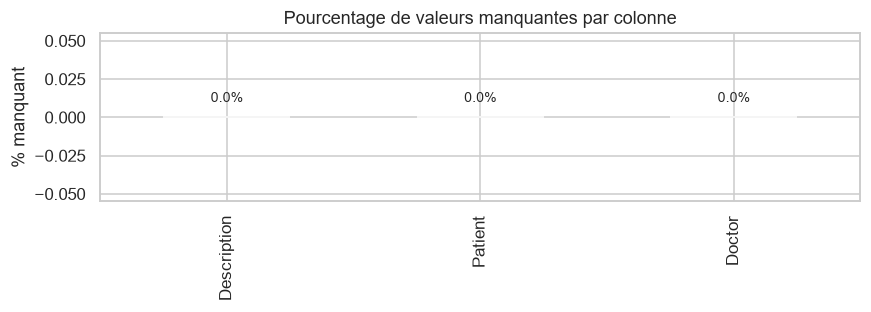

In [8]:
# --- 1.2 Valeurs manquantes ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Valeurs manquantes": missing,
    "Pourcentage (%)": missing_pct
})
print("--- Valeurs manquantes par colonne ---")
print(missing_df)

fig, ax = plt.subplots(figsize=(8, 3))
colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in missing_pct]
missing_pct.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Pourcentage de valeurs manquantes par colonne")
ax.set_ylabel("% manquant")
ax.set_xlabel("")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                ha="center", fontsize=9)
plt.tight_layout()
plt.show()

---
## 2. Analyse Exploratoire des Données (EDA)

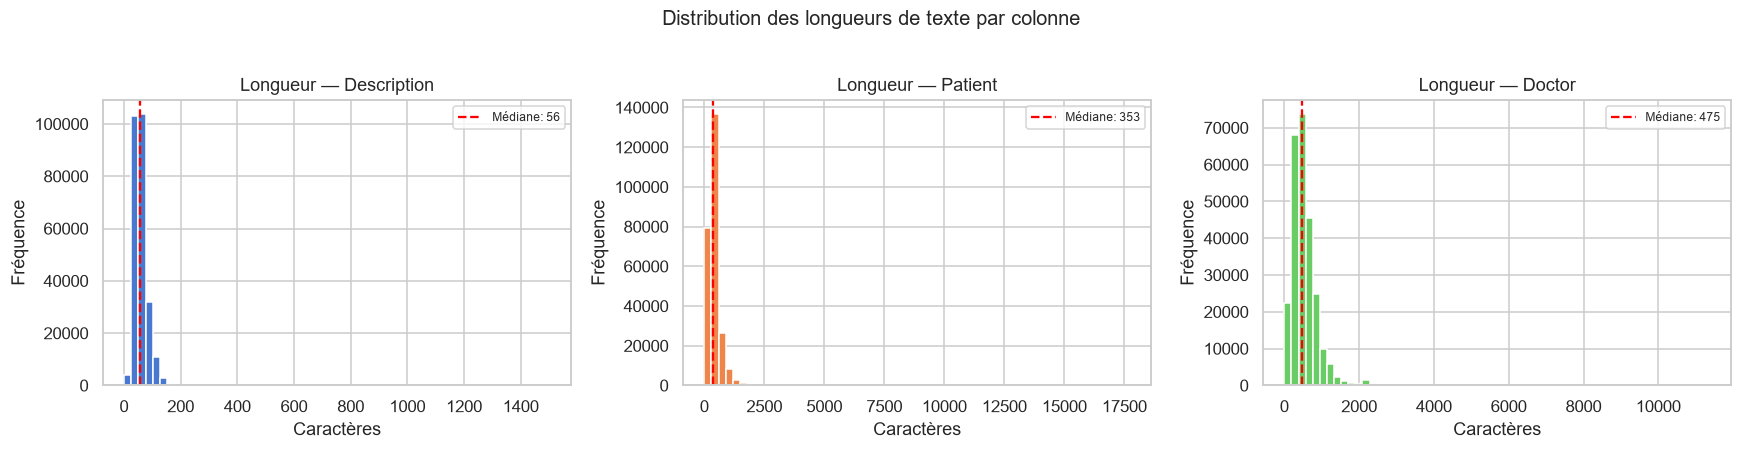

In [9]:
# --- 2.1 Distribution des longueurs de texte (caractères) ---
for col in ["Description", "Patient", "Doctor"]:
    df[f"len_{col.lower()}"] = df[col].fillna("").apply(len)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette = sns.color_palette("muted")
for i, col in enumerate(["Description", "Patient", "Doctor"]):
    col_len = f"len_{col.lower()}"
    axes[i].hist(df[col_len], bins=60, color=palette[i], edgecolor="white")
    axes[i].set_title(f"Longueur — {col}")
    axes[i].set_xlabel("Caractères")
    axes[i].set_ylabel("Fréquence")
    median = df[col_len].median()
    axes[i].axvline(median, color="red", linestyle="--", label=f"Médiane: {median:.0f}")
    axes[i].legend(fontsize=8)
plt.suptitle("Distribution des longueurs de texte par colonne", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# --- 2.2 Statistiques descriptives des longueurs ---
len_cols = ["len_description", "len_patient", "len_doctor"]
stats = df[len_cols].describe().round(1)
stats.index = ["count", "mean", "std", "min", "25%", "50% (médiane)", "75%", "max"]
print("--- Statistiques descriptives (longueurs en caractères) ---")
print(stats.to_string())

--- Statistiques descriptives (longueurs en caractères) ---
               len_description  len_patient  len_doctor
count                 256916.0     256916.0    256916.0
mean                      59.4        436.5       537.4
std                       22.3        299.4       338.7
min                        1.0          1.0         2.0
25%                       44.0        283.0       318.0
50% (médiane)             56.0        353.0       475.0
75%                       70.0        491.0       675.0
max                     1503.0      17735.0     11385.0


--- Estimation tokens par colonne ---
       tokens_description  tokens_patient  tokens_doctor  tokens_total
count              256916          256916         256916        256916
mean                   14             109            134           257
std                     6              75             85           118
min                     0               0              0            19
25%                    11              70             79           184
50%                    14              88            118           234
75%                    17             122            168           300
max                   375            4433           2846          4690

Conversations dépassant 2048 tokens (limite LoRA) : 22 (0.0%)


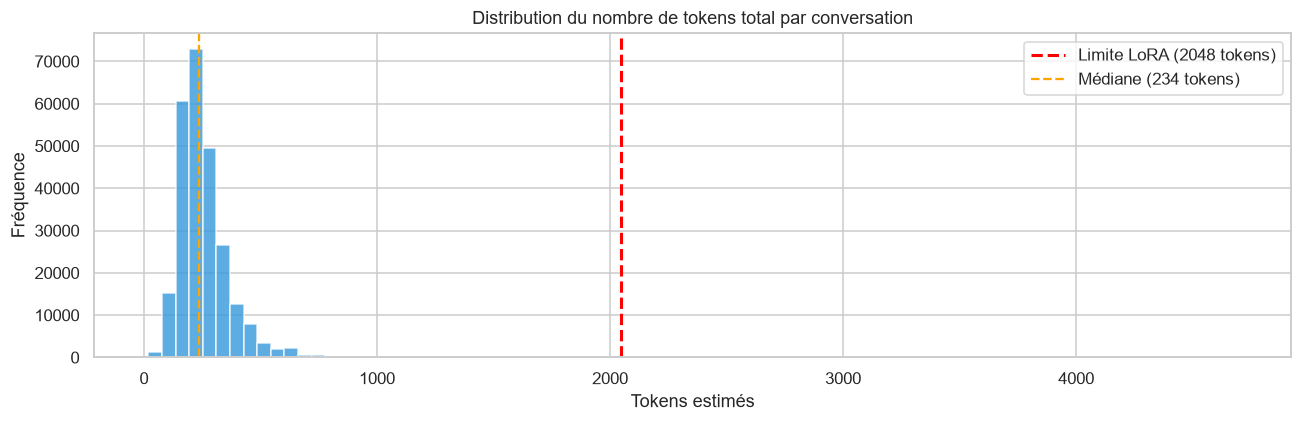

In [11]:
# --- 2.3 Estimation du nombre de tokens (~4 caractères / token) ---
CHARS_PER_TOKEN = 4
LORA_CONTEXT_LIMIT = 2048

for col in ["Description", "Patient", "Doctor"]:
    df[f"tokens_{col.lower()}"] = (df[f"len_{col.lower()}"] / CHARS_PER_TOKEN).astype(int)

df["tokens_total"] = df["tokens_description"] + df["tokens_patient"] + df["tokens_doctor"]

print("--- Estimation tokens par colonne ---")
print(df[["tokens_description", "tokens_patient", "tokens_doctor", "tokens_total"]].describe().round(0).astype(int))

over_limit = (df["tokens_total"] > LORA_CONTEXT_LIMIT).sum()
print(f"\nConversations dépassant {LORA_CONTEXT_LIMIT} tokens (limite LoRA) : "
      f"{over_limit} ({over_limit / len(df) * 100:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df["tokens_total"], bins=80, color="#3498db", edgecolor="white", alpha=0.8)
ax.axvline(LORA_CONTEXT_LIMIT, color="red", linestyle="--", linewidth=2,
           label=f"Limite LoRA ({LORA_CONTEXT_LIMIT} tokens)")
ax.axvline(df["tokens_total"].median(), color="orange", linestyle="--", linewidth=1.5,
           label=f"Médiane ({df['tokens_total'].median():.0f} tokens)")
ax.set_title("Distribution du nombre de tokens total par conversation")
ax.set_xlabel("Tokens estimés")
ax.set_ylabel("Fréquence")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Tests de Qualité des Conversations

In [12]:
# --- 3.1 Détection des doublons ---
n_exact_dup   = df.duplicated(subset=["Patient", "Doctor"]).sum()
n_desc_dup    = df.duplicated(subset=["Description"]).sum()
n_patient_dup = df.duplicated(subset=["Patient"]).sum()

print("--- Doublons détectés ---")
print(f"  Lignes exactement dupliquées (Patient + Doctor) : {n_exact_dup:>6,}")
print(f"  Descriptions dupliquées                         : {n_desc_dup:>6,}")
print(f"  Questions Patient dupliquées                    : {n_patient_dup:>6,}")

--- Doublons détectés ---
  Lignes exactement dupliquées (Patient + Doctor) : 10,389
  Descriptions dupliquées                         : 28,194
  Questions Patient dupliquées                    : 10,910


--- Problèmes de qualité détectés ---
                    Nombre de lignes  Pourcentage (%)
patient_vide                       0             0.00
doctor_vide                        0             0.00
description_vide                   0             0.00
patient_trop_court                49             0.02
doctor_trop_court                105             0.04
tokens_over_limit                 22             0.01


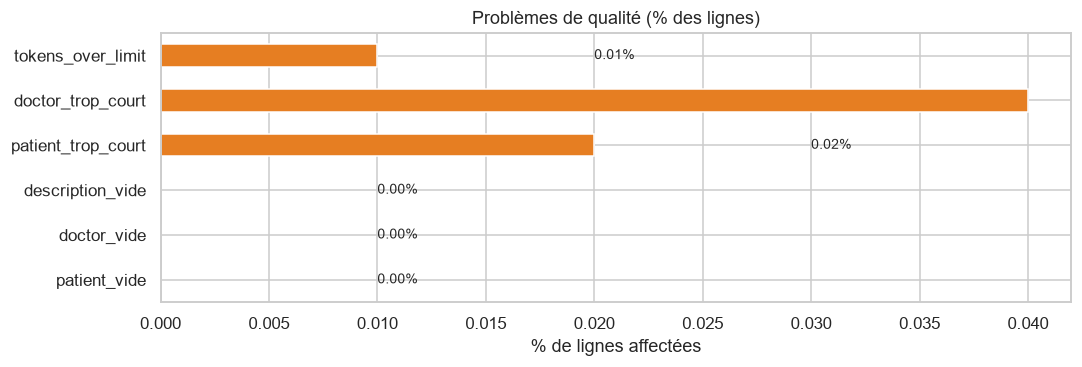

In [13]:
# --- 3.2 Entrées vides ou trop courtes ---
MIN_PATIENT_LEN = 20
MIN_DOCTOR_LEN  = 30

issues = pd.DataFrame({
    "patient_vide":       df["Patient"].fillna("").str.strip().eq(""),
    "doctor_vide":        df["Doctor"].fillna("").str.strip().eq(""),
    "description_vide":   df["Description"].fillna("").str.strip().eq(""),
    "patient_trop_court": df["len_patient"] < MIN_PATIENT_LEN,
    "doctor_trop_court":  df["len_doctor"]  < MIN_DOCTOR_LEN,
    "tokens_over_limit":  df["tokens_total"] > LORA_CONTEXT_LIMIT,
})

print("--- Problèmes de qualité détectés ---")
summary_issues = issues.sum().to_frame("Nombre de lignes")
summary_issues["Pourcentage (%)"] = (summary_issues["Nombre de lignes"] / len(df) * 100).round(2)
print(summary_issues)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 3.5))
summary_issues["Pourcentage (%)"].plot(kind="barh", ax=ax, color="#e67e22")
ax.set_title("Problèmes de qualité (% des lignes)")
ax.set_xlabel("% de lignes affectées")
for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}%",
                (p.get_width() + 0.01, p.get_y() + p.get_height() / 2),
                va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [14]:
# --- 3.3 Détection de patterns indésirables ---
def detect_patterns(text):
    found = []
    t = str(text)
    if re.search(r"https?://", t):           found.append("URL")
    if re.search(r"<[^>]+>", t):            found.append("HTML")
    if re.search(r"[^\x00-\x7F]", t):       found.append("NON_ASCII")
    if re.match(r"^\s*[QA]\.", t):           found.append("PREFIX_QA")
    if re.search(r"\b(\w)\1{4,}\b", t):     found.append("SPAM_REPEAT")
    return "|".join(found) if found else "OK"

df["desc_patterns"]    = df["Description"].apply(detect_patterns)
df["patient_patterns"] = df["Patient"].apply(detect_patterns)
df["doctor_patterns"]  = df["Doctor"].apply(detect_patterns)

for col, label in zip(
        ["desc_patterns", "patient_patterns", "doctor_patterns"],
        ["Description", "Patient", "Doctor"]):
    counts = df[col].str.split("|").explode().value_counts()
    print(f"\n{label} :\n{counts.to_string()}")


Description :
desc_patterns
OK           225862
PREFIX_QA     30979
NON_ASCII        43
HTML             35

Patient :
patient_patterns
OK             244899
NON_ASCII       11611
SPAM_REPEAT       395
HTML               13
PREFIX_QA           5

Doctor :
doctor_patterns
OK             244012
NON_ASCII       12847
SPAM_REPEAT        52
HTML               19


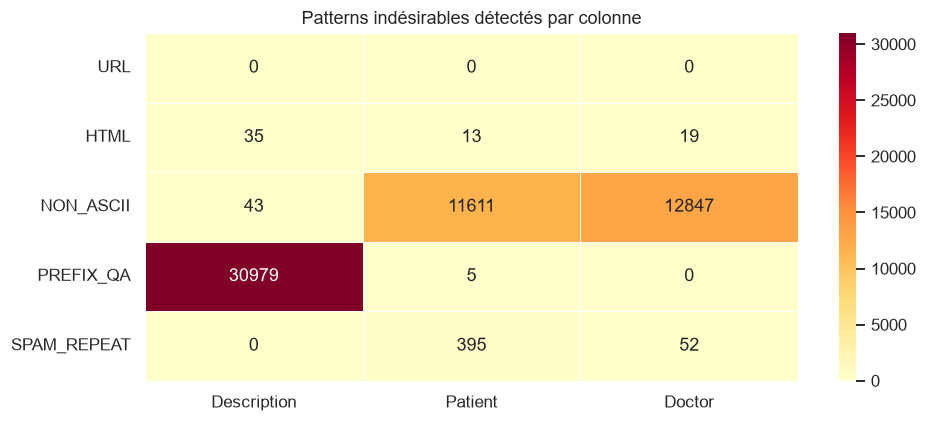

In [15]:
# --- 3.4 Heatmap des patterns indésirables ---
pattern_flags = ["URL", "HTML", "NON_ASCII", "PREFIX_QA", "SPAM_REPEAT"]
heat_data = {}
for flag in pattern_flags:
    heat_data[flag] = {
        "Description": df["desc_patterns"].str.contains(flag).sum(),
        "Patient":      df["patient_patterns"].str.contains(flag).sum(),
        "Doctor":       df["doctor_patterns"].str.contains(flag).sum(),
    }
heat_df = pd.DataFrame(heat_data).T

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heat_df, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Patterns indésirables détectés par colonne")
plt.tight_layout()
plt.show()

---
## 4. Nettoyage du Dataset

In [16]:
# --- 4.1 Pipeline de nettoyage ---
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)      # Supprime balises HTML
    text = re.sub(r"\s+", " ", text)            # Normalise les espaces
    return text.strip()

df_clean = df[["Description", "Patient", "Doctor"]].copy()
for col in ["Description", "Patient", "Doctor"]:
    df_clean[col] = df_clean[col].apply(clean_text)

# Filtre lignes trop courtes
mask_valid = (
    df_clean["Patient"].str.len().gt(MIN_PATIENT_LEN) &
    df_clean["Doctor"].str.len().gt(MIN_DOCTOR_LEN)
)
df_clean = df_clean[mask_valid]
n_before = len(df_clean)

# Dédoublonnage
df_clean = df_clean.drop_duplicates(subset=["Patient", "Doctor"]).reset_index(drop=True)
n_after = len(df_clean)

print(f"{'Lignes brutes (raw)':<35} : {len(df):>8,}")
print(f"{'Après filtrage (trop courts)':<35} : {n_before:>8,}")
print(f"{'Après dédoublonnage':<35} : {n_after:>8,}")
print(f"{'Lignes supprimées':<35} : {len(df) - n_after:>8,}  ({(len(df)-n_after)/len(df)*100:.1f}%)")

Lignes brutes (raw)                 :  256,916
Après filtrage (trop courts)        :  256,751
Après dédoublonnage                 :  246,361
Lignes supprimées                   :   10,555  (4.1%)


--- Statistiques post-nettoyage ---
       len_patient  len_doctor  tokens_total
count     246361.0    246361.0      246361.0
mean         438.3       527.7         255.9
std          301.5       314.5         114.5
min           21.0        31.0          25.0
25%          285.0       319.0         184.0
50%          353.0       468.0         234.0
75%          488.0       668.0         299.0
max        17735.0     11385.0        4691.0

Conversations > 2048 tokens : 21


C:\Users\lecha\AppData\Local\Temp\ipykernel_18192\4245687468.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df_clean[col].dropna(), vert=False, patch_artist=True,
C:\Users\lecha\AppData\Local\Temp\ipykernel_18192\4245687468.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df_clean[col].dropna(), vert=False, patch_artist=True,


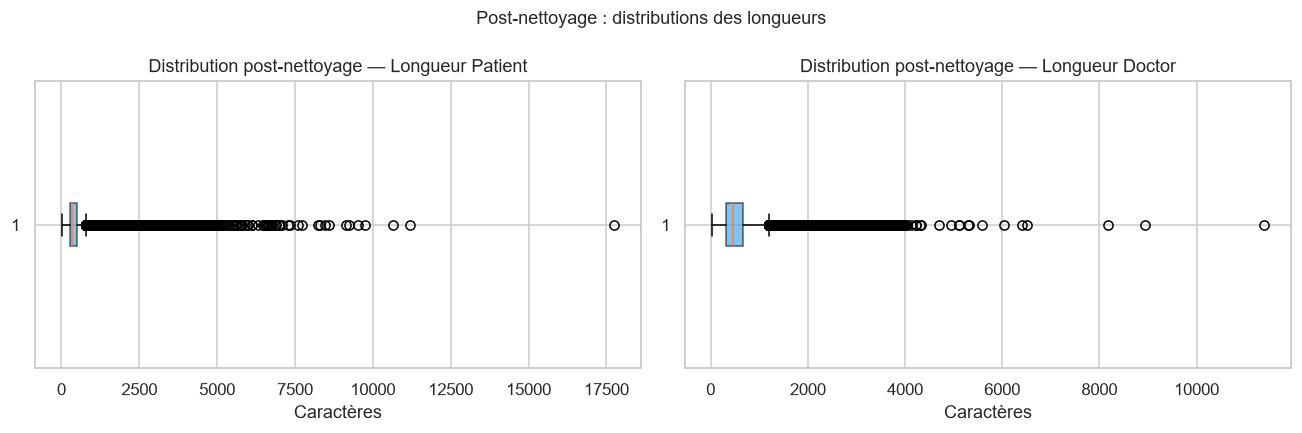

In [17]:
# --- 4.2 Vérification post-nettoyage ---
df_clean["len_patient"] = df_clean["Patient"].str.len()
df_clean["len_doctor"]  = df_clean["Doctor"].str.len()
df_clean["tokens_total"] = (
    (df_clean["len_patient"] + df_clean["len_doctor"] + df_clean["Description"].str.len())
    / CHARS_PER_TOKEN
).astype(int)

print("--- Statistiques post-nettoyage ---")
print(df_clean[["len_patient", "len_doctor", "tokens_total"]].describe().round(1))
print(f"\nConversations > {LORA_CONTEXT_LIMIT} tokens : {(df_clean['tokens_total'] > LORA_CONTEXT_LIMIT).sum():,}")

# Boxplots comparatifs avant / après
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(
        axes,
        ["len_patient", "len_doctor"],
        ["Longueur Patient", "Longueur Doctor"]):
    ax.boxplot(df_clean[col].dropna(), vert=False, patch_artist=True,
               boxprops=dict(facecolor="#3498db", alpha=0.6))
    ax.set_title(f"Distribution post-nettoyage — {label}")
    ax.set_xlabel("Caractères")
plt.suptitle("Post-nettoyage : distributions des longueurs", fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Préparation pour le Fine-Tuning LoRA (Format Phi-3.5 / ChatML)

In [18]:
# --- 5.1 Formatage Alpaca-style (instruction / input / output) ---
SYSTEM_PROMPT = (
    "You are a knowledgeable and compassionate medical assistant. "
    "Answer the patient's question accurately and clearly based on medical knowledge. "
    "Always recommend consulting a licensed physician for diagnosis and treatment."
)

def build_lora_sample(row):
    return {
        "instruction": SYSTEM_PROMPT,
        "input":   row["Patient"].strip(),
        "output":  row["Doctor"].strip(),
        "context": row["Description"].strip(),
    }

df_lora = df_clean[["Description", "Patient", "Doctor"]].apply(
    build_lora_sample, axis=1, result_type="expand"
)
print(f"Dataset LoRA (Alpaca) : {len(df_lora):,} exemples")
df_lora.head(2)

Dataset LoRA (Alpaca) : 246,361 exemples


,instruction,input,output,context
0,You are a knowledgeable and compassionate medi...,"Hi doctor,I am just wondering what is abutting...",Hi. I have gone through your query with dilige...,Q. What does abutment of the nerve root mean?
1,You are a knowledgeable and compassionate medi...,"Hi doctor, I am a 22-year-old female who was d...",Hi. You have really done well with the hypothy...,Q. What should I do to reduce my weight gained...


Exemples dans la limite 2048 tokens : 246,337 / 246,361
Exclus (trop longs)                          : 24 (0.0%)


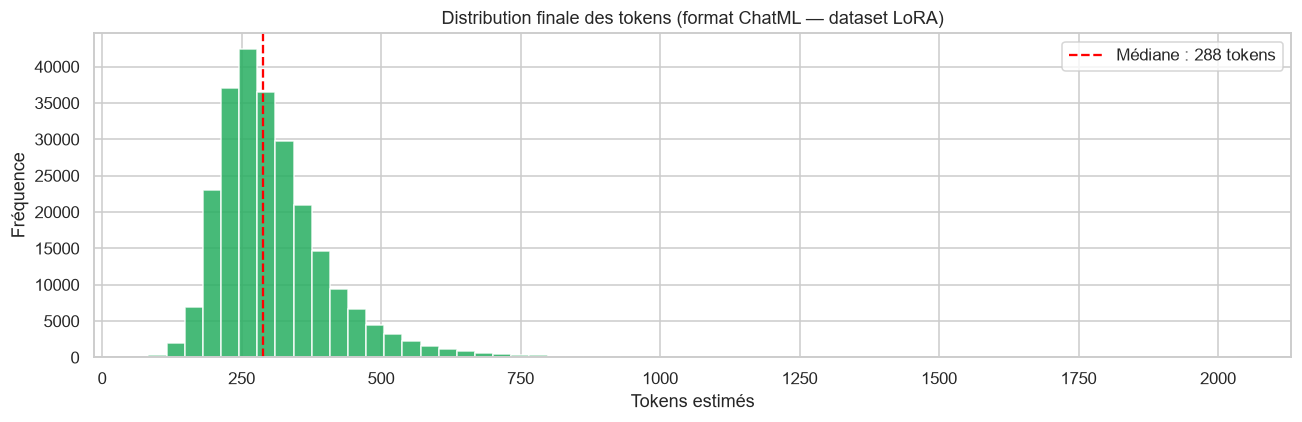

In [22]:
# --- 5.2 Formatage ChatML (compatible Phi-3.5 / Phi-3.5-mini) ---
def to_chatml(row):
    return (
        f"<|system|>\n{row['instruction']}<|end|>\n"
        f"<|user|>\n{row['input']}<|end|>\n"
        f"<|assistant|>\n{row['output']}<|end|>"
    )

df_lora["chatml"]        = df_lora.apply(to_chatml, axis=1)
df_lora["chatml_tokens"] = (df_lora["chatml"].str.len() / CHARS_PER_TOKEN).astype(int)

# Filtrage sur limite de contexte
df_lora_filtered = df_lora[df_lora["chatml_tokens"] <= LORA_CONTEXT_LIMIT].copy()
n_excluded = len(df_lora) - len(df_lora_filtered)

print(f"Exemples dans la limite {LORA_CONTEXT_LIMIT} tokens : {len(df_lora_filtered):,} / {len(df_lora):,}")
print(f"Exclus (trop longs)                          : {n_excluded:,} ({n_excluded/len(df_lora)*100:.1f}%)")

# Distribution tokens finale
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df_lora_filtered["chatml_tokens"], bins=60, color="#27ae60", edgecolor="white", alpha=0.85)
ax.axvline(df_lora_filtered["chatml_tokens"].median(), color="red", linestyle="--",
           label=f"Médiane : {df_lora_filtered['chatml_tokens'].median():.0f} tokens")
ax.set_title("Distribution finale des tokens (format ChatML — dataset LoRA)")
ax.set_xlabel("Tokens estimés")
ax.set_ylabel("Fréquence")
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# --- 5.3 Split Train / Validation (90 / 10) ---
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(df_lora_filtered, test_size=0.1, random_state=42)
print(f"Train      : {len(df_train):>7,} exemples  ({len(df_train)/len(df_lora_filtered)*100:.0f}%)")
print(f"Validation : {len(df_val):>7,} exemples  ({len(df_val)/len(df_lora_filtered)*100:.0f}%)")
print(f"Total      : {len(df_lora_filtered):>7,} exemples")

Train      : 221,703 exemples  (90%)
Validation :  24,634 exemples  (10%)
Total      : 246,337 exemples


In [24]:
# --- 5.4 Export JSONL ---
output_cols = ["instruction", "input", "output", "context"]
train_path  = "dataset_lora_train.jsonl"
val_path    = "dataset_lora_val.jsonl"

df_train[output_cols].to_json(train_path, orient="records", lines=True, force_ascii=False)
df_val[output_cols].to_json(val_path,   orient="records", lines=True, force_ascii=False)

print("Fichiers exportés :")
print(f"  {train_path}  ({len(df_train):,} lignes)")
print(f"  {val_path}    ({len(df_val):,} lignes)")

# Vérification lecture
with open(train_path, "r", encoding="utf-8") as f:
    sample = json.loads(f.readline())
print("\n--- Exemple (1er enregistrement train) ---")
for k, v in sample.items():
    print(f"  [{k}] : {str(v)[:100]}...")

Fichiers exportés :
  dataset_lora_train.jsonl  (221,703 lignes)
  dataset_lora_val.jsonl    (24,634 lignes)

--- Exemple (1er enregistrement train) ---
  [instruction] : You are a knowledgeable and compassionate medical assistant. Answer the patient's question accuratel...
  [input] : My husband had an mri done and it says involutional changes are noted throughout the brain, it also ...
  [output] : Cortical damage to brain n ischemia means your body doesn't supply or poorly supply blood to brain. ...
  [context] : What does this MRI report of brain indicate?...


---
## 6. Rapport de Qualité — Synthèse

In [25]:
# --- 6.1 Tableau de synthèse ---
report_rows = [
    ("Lignes brutes (raw)",                   len(df)),
    ("Doublons exacts supprimés",             n_exact_dup),
    ("Lignes trop courtes supprimées",        len(df) - n_before),
    ("Lignes valides après nettoyage",        n_after),
    ("Conversations > 2048 tokens exclues",   n_excluded),
    ("Dataset final (LoRA train + val)",      len(df_lora_filtered)),
    ("Split Train",                           len(df_train)),
    ("Split Validation",                      len(df_val)),
    ("Taux de rétention (%)",                 f"{len(df_lora_filtered) / len(df) * 100:.1f}"),
    ("Médiane tokens / conversation",         int(df_lora_filtered['chatml_tokens'].median())),
    ("Max tokens / conversation",             int(df_lora_filtered['chatml_tokens'].max())),
]
report_df = pd.DataFrame(report_rows, columns=["Métrique", "Valeur"])

print("=" * 57)
print("        RAPPORT DE QUALITÉ — DATASET MÉDICAL")
print("=" * 57)
print(report_df.to_string(index=False))
print("=" * 57)

        RAPPORT DE QUALITÉ — DATASET MÉDICAL
                           Métrique Valeur
                Lignes brutes (raw) 256916
          Doublons exacts supprimés  10389
     Lignes trop courtes supprimées    165
     Lignes valides après nettoyage 246361
Conversations > 2048 tokens exclues     24
   Dataset final (LoRA train + val) 246337
                        Split Train 221703
                   Split Validation  24634
              Taux de rétention (%)   95.9
      Médiane tokens / conversation    288
          Max tokens / conversation   2034


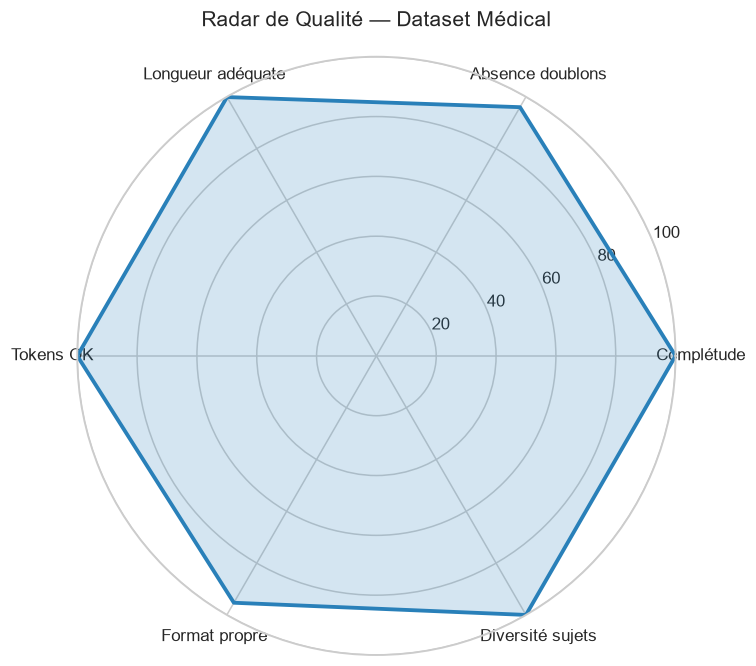


Scores de qualité :
  Complétude             ██████████  100.0%
  Absence doublons       █████████░  96.0%
  Longueur adéquate      █████████░  99.9%
  Tokens OK              ██████████  100.0%
  Format propre          █████████░  95.3%
  Diversité sujets       ██████████  100.0%


In [26]:
# --- 6.2 Radar de qualité ---
categories = [
    "Complétude",
    "Absence doublons",
    "Longueur adéquate",
    "Tokens OK",
    "Format propre",
    "Diversité sujets",
]

completeness  = round((1 - issues[["patient_vide", "doctor_vide"]].any(axis=1).sum() / len(df)) * 100, 1)
dedup_score   = round((1 - n_exact_dup / len(df)) * 100, 1)
length_score  = round(mask_valid.sum() / len(df) * 100, 1)
token_score   = round(len(df_lora_filtered) / max(n_after, 1) * 100, 1)
clean_score   = round((1 - df["patient_patterns"].ne("OK").sum() / len(df)) * 100, 1)
unique_words  = df_clean["Description"].str.lower().str.split().explode().nunique()
diversity     = min(round(unique_words / 5000 * 100, 1), 100.0)

scores = [completeness, dedup_score, length_score, token_score, clean_score, diversity]

N      = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles_plot = angles + angles[:1]
scores_plot = scores + scores[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles_plot, scores_plot, color="#2980b9", linewidth=2.5)
ax.fill(angles_plot, scores_plot, color="#2980b9", alpha=0.20)
ax.set_xticks(angles)
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_title("Radar de Qualité — Dataset Médical", size=14, pad=20)
for angle, score in zip(angles, scores):
    ax.annotate(f"{score:.0f}%", xy=(angle, score + 5), ha="center", fontsize=9, color="#2c3e50")
plt.tight_layout()
plt.show()

print("\nScores de qualité :")
for cat, sc in zip(categories, scores):
    bar = "█" * int(sc // 10) + "░" * (10 - int(sc // 10))
    print(f"  {cat:<22} {bar}  {sc:.1f}%")